# SMLM PCF Pipeline: Compare Conditions

This notebook overlays pooled PCF curves from multiple results folders. Run `SMLM_PCF_Plotting.ipynb` for each condition first so every folder contains `aggregated_pooled_pcf_results.csv`.

### Steps:
1. **Configure**: Define conditions, choose auto-left, auto-right, or cross PCF, and assign colors.
2. **Load**: Read pooled PCF tables from each results folder and validate compatible distance bins.
3. **Compare**: Save a long-form comparison CSV and generate an overlay plot with mean +/- SEM.

### Step 1: Configuration

In [37]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PARAMETERS - edit these
# ==========================================
# Each condition should point to a results folder that already contains
# aggregated_pooled_pcf_results.csv from SMLM_PCF_Plotting.ipynb.
conditions = [
    {
        'label': 'undifferentiated',
        'results_dir': '/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/undiff',
    },
    {
        'label': 'Aux 1h',
        'results_dir': '/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/Aux1h',
    },
    {
        'label': 'Aux 24h',
        'results_dir': '/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/Aux24h',
    },
    {
        'label': 'Dox 24h',
        'results_dir': '/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/Dox24h',
    },
]

# Choose one: 'auto_left', 'auto_right', or 'cross'
pcf_to_compare = 'auto_left'

left_label  = 'SPEN'
right_label = 'H3K27ac'

# Used when a condition does not define its own color. Can be a list or a
# dictionary mapping condition labels to colors.
color_scheme = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9']

# If None, outputs are saved in the current notebook working directory.
comparison_output_dir = '/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/'
comparison_basename = f'comparison_{pcf_to_compare}_pcf'

if comparison_output_dir is None:
    comparison_output_dir = os.getcwd()

comparison_png_path = os.path.join(comparison_output_dir, f'{comparison_basename}.png')
comparison_csv_path = os.path.join(comparison_output_dir, f'{comparison_basename}.csv')

print('Comparison parameters loaded successfully!')

Comparison parameters loaded successfully!


### Step 2: Helper Functions

In [38]:
PCF_COLUMN_MAP = {
    'auto_left':  ('mean_G_auto_left',  'sem_G_auto_left'),
    'auto_right': ('mean_G_auto_right', 'sem_G_auto_right'),
    'cross':      ('mean_G_cross',      'sem_G_cross'),
}

PCF_TITLE_MAP = {
    'auto_left':  lambda left, right: f'Auto-Pair Correlation Function, {left}',
    'auto_right': lambda left, right: f'Auto-Pair Correlation Function, {right}',
    'cross':      lambda left, right: f'Cross-Correlation Function, {left} vs {right}',
}


def validate_pcf_choice(pcf_choice):
    if pcf_choice not in PCF_COLUMN_MAP:
        valid = ', '.join(sorted(PCF_COLUMN_MAP))
        raise ValueError(f"pcf_to_compare must be one of: {valid}. Got: {pcf_choice!r}")


def get_condition_color(condition, idx, scheme):
    if condition.get('color'):
        return condition['color']
    if isinstance(scheme, dict):
        label = condition['label']
        if label not in scheme:
            raise ValueError(f"No color provided for condition {label!r} in color_scheme dict")
        return scheme[label]
    if len(scheme) == 0:
        raise ValueError('color_scheme list must contain at least one color')
    return scheme[idx % len(scheme)]


def infer_n_nuclei(results_dir):
    nucleus_csvs = glob.glob(os.path.join(results_dir, '*_nucleus_*_pcf.csv'))
    if len(nucleus_csvs) == 0:
        return np.nan
    return len(nucleus_csvs)


def load_condition_pcf(condition, pcf_choice):
    validate_pcf_choice(pcf_choice)

    label = condition['label']
    results_dir = condition['results_dir']
    pooled_csv_path = os.path.join(results_dir, 'aggregated_pooled_pcf_results.csv')
    mean_col, sem_col = PCF_COLUMN_MAP[pcf_choice]

    if not os.path.isdir(results_dir):
        raise FileNotFoundError(f"Results folder does not exist for {label!r}: {results_dir}")
    if not os.path.isfile(pooled_csv_path):
        raise FileNotFoundError(
            f"Missing pooled CSV for {label!r}: {pooled_csv_path}. "
            "Run SMLM_PCF_Plotting.ipynb for this condition first."
        )

    df = pd.read_csv(pooled_csv_path)
    required_cols = ['r_center_nm', mean_col, sem_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(
            f"Pooled CSV for {label!r} is missing required columns: {missing_cols}. "
            f"Available columns: {list(df.columns)}"
        )

    out = pd.DataFrame({
        'condition': label,
        'results_dir': results_dir,
        'pcf_type': pcf_choice,
        'r_center_nm': df['r_center_nm'].to_numpy(dtype=float),
        'mean_G': df[mean_col].to_numpy(dtype=float),
        'sem_G': df[sem_col].to_numpy(dtype=float),
        'n_nuclei': infer_n_nuclei(results_dir),
    })
    return out


def validate_matching_r_bins(comparison_df):
    reference = None
    reference_label = None
    for label, group in comparison_df.groupby('condition', sort=False):
        r_values = group['r_center_nm'].to_numpy(dtype=float)
        if reference is None:
            reference = r_values
            reference_label = label
            continue
        if len(r_values) != len(reference) or not np.allclose(r_values, reference, rtol=1e-7, atol=1e-9):
            raise ValueError(
                f"Distance bins do not match between {reference_label!r} and {label!r}. "
                "Re-run plotting with matching PCF bin parameters before comparing."
            )



def make_legend_label(condition_label, n_nuclei):
    if pd.isna(n_nuclei):
        return condition_label
    return f'{condition_label} (N = {int(n_nuclei)} nuclei)'


def pcf_plot_title(pcf_choice, left, right):
    validate_pcf_choice(pcf_choice)
    return PCF_TITLE_MAP[pcf_choice](left, right)

### Step 3: Load, Validate, and Save Comparison Table

In [39]:
if len(conditions) == 0:
    raise ValueError('Define at least one condition in the configuration cell.')

comparison_frames = []
for idx, condition in enumerate(conditions):
    if 'label' not in condition or 'results_dir' not in condition:
        raise ValueError(f"Condition at index {idx} must include 'label' and 'results_dir': {condition}")

    condition = dict(condition)
    condition['color'] = get_condition_color(condition, idx, color_scheme)
    condition_df = load_condition_pcf(condition, pcf_to_compare)
    condition_df['color'] = condition['color']
    comparison_frames.append(condition_df)

comparison_df = pd.concat(comparison_frames, ignore_index=True)
validate_matching_r_bins(comparison_df)

os.makedirs(comparison_output_dir, exist_ok=True)
comparison_df.to_csv(comparison_csv_path, index=False)

print(f'Loaded {comparison_df["condition"].nunique()} condition(s).')
print(f'Comparison table saved to: {comparison_csv_path}')
comparison_df.head()

Loaded 4 condition(s).
Comparison table saved to: /Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/comparison_auto_left_pcf.csv


,condition,results_dir,pcf_type,r_center_nm,mean_G,sem_G,n_nuclei,color
0,undifferentiated,/Volumes/guttman/users/gmgao/Imaging_Processed...,auto_left,50.0,3.544253,0.463867,8,#0072B2
1,undifferentiated,/Volumes/guttman/users/gmgao/Imaging_Processed...,auto_left,70.0,2.868481,0.309995,8,#0072B2
2,undifferentiated,/Volumes/guttman/users/gmgao/Imaging_Processed...,auto_left,90.0,2.273113,0.178350,8,#0072B2
3,undifferentiated,/Volumes/guttman/users/gmgao/Imaging_Processed...,auto_left,110.0,1.891273,0.099173,8,#0072B2
4,undifferentiated,/Volumes/guttman/users/gmgao/Imaging_Processed...,auto_left,130.0,1.678147,0.060376,8,#0072B2


### Step 4: Publication-Quality Overlay Plot

Plot saved to: /Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-dSTORM/comparison_auto_left_pcf.png


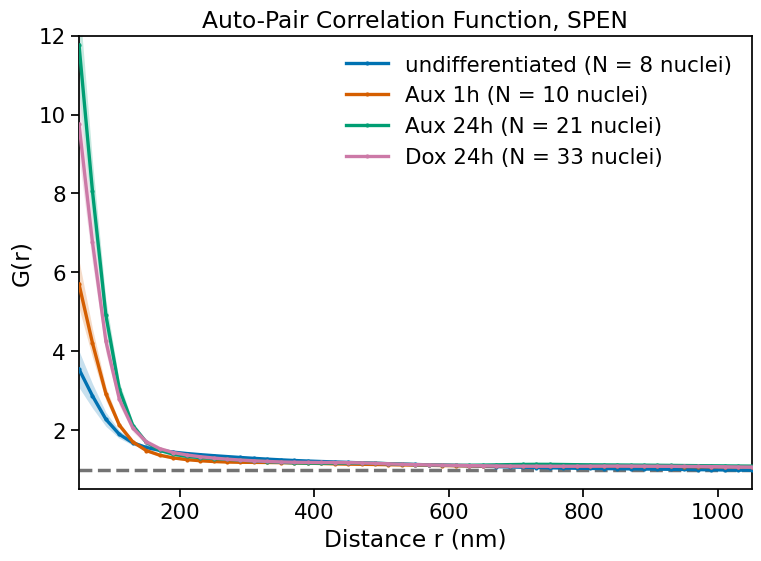

In [41]:
sns.set_context('notebook', font_scale=1.4)
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5), constrained_layout=True)

for condition_label, group in comparison_df.groupby('condition', sort=False):
    group = group.sort_values('r_center_nm')
    x = group['r_center_nm'].to_numpy(dtype=float)
    mean = group['mean_G'].to_numpy(dtype=float)
    sem = group['sem_G'].to_numpy(dtype=float)
    color = group['color'].iloc[0]
    n_nuclei = group['n_nuclei'].iloc[0]
    legend_label = make_legend_label(condition_label, n_nuclei)

    ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.22, linewidth=0, zorder=2)
    ax.plot(x, mean, color=color, lw=2.4, marker='.', markersize=4, label=legend_label, zorder=3)

ax.axhline(1, color='0.45', ls='--', lw=2.5, zorder=1)
ax.set_xlim(comparison_df['r_center_nm'].min(), comparison_df['r_center_nm'].max())
ax.set_xlabel('Distance r (nm)')
ax.set_ylabel('G(r)')
ax.set_title(pcf_plot_title(pcf_to_compare, left_label, right_label))
ax.set_ylim(0.5, 12)
ax.legend(frameon=False, loc='best')

fig.savefig(comparison_png_path, dpi=300, bbox_inches='tight')
print(f'Plot saved to: {comparison_png_path}')
plt.show()